<a href="https://colab.research.google.com/github/laodeazwaraiman/tugas2ml/blob/main/AIfixx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import files
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Menghilangkan peringatan teknis
warnings.filterwarnings("ignore")

print("1. DATA UNDERSTANDING")
print("Silakan unggah file Walmart.csv:")
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

print("\n--- Statistik Deskriptif ---")
display(df.describe())
print("\n--- Informasi Dataset ---")
display(df.info())


1. DATA UNDERSTANDING
Silakan unggah file Walmart.csv:


Saving Walmart.csv to Walmart (1).csv

--- Statistik Deskriptif ---


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


None

2. DATA PREPROCESSING & 3. EDA


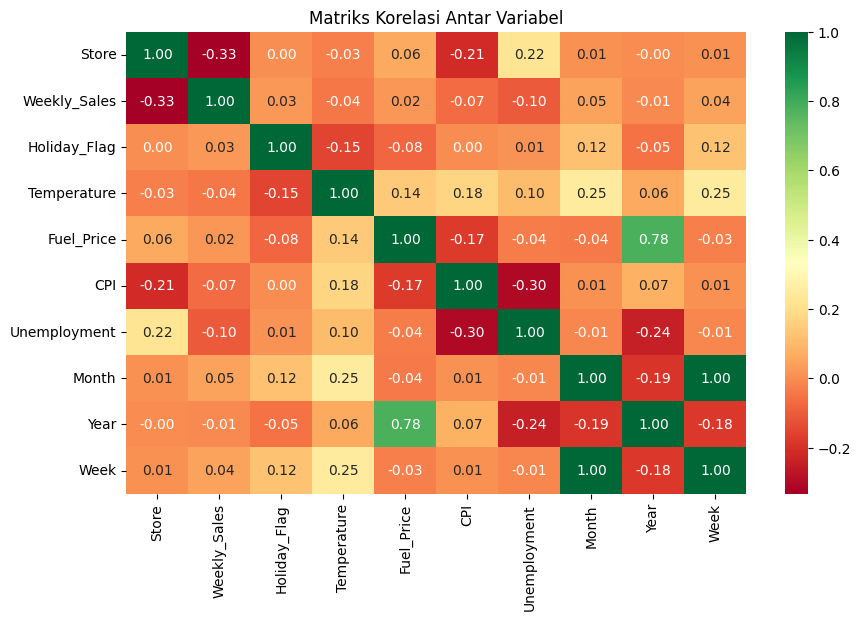

✅ Preprocessing Selesai. Baris data setelah cleaning: 6401


In [7]:
print("2. DATA PREPROCESSING & 3. EDA")

# Preprocessing: Konversi Tanggal
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

# Menangani Outlier pada Target (Weekly_Sales) menggunakan metode IQR
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_clean = df[(df['Weekly_Sales'] >= lower_bound) & (df['Weekly_Sales'] <= upper_bound)]

# Visualisasi EDA: Heatmap Korelasi
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.drop('Date', axis=1).corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Matriks Korelasi Antar Variabel")
plt.show()

# Drop kolom Date untuk modeling
df_model = df_clean.drop(['Date'], axis=1)
print(f"✅ Preprocessing Selesai. Baris data setelah cleaning: {len(df_model)}")

In [8]:
print("4. DATA SPLITTING")

X = df_model.drop('Weekly_Sales', axis=1)
y = df_model['Weekly_Sales']

# Variasi Rasio: 70:30, 80:20, 90:10
ratios = [0.3, 0.2, 0.1]
split_names = ["70:30", "80:20", "90:10"]
split_data = {}

for ratio, name in zip(ratios, split_names):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ratio, random_state=42)

    # Standarisasi
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    split_data[name] = (X_train_scaled, X_test_scaled, y_train, y_test, scaler)

print("✅ Eksperimen 3 variasi data splitting berhasil disiapkan.")

4. DATA SPLITTING
✅ Eksperimen 3 variasi data splitting berhasil disiapkan.


In [9]:
print("5. MODEL BUILDING & 6. HYPERPARAMETER TUNING")

results = []
best_overall_model = None
best_r2 = 0
final_scaler = None

# Definisi Algoritma dan Parameter untuk Tuning
model_params = {
    "Linear Regression": (LinearRegression(), {}),
    "Decision Tree": (DecisionTreeRegressor(random_state=42), {
        'max_depth': [10, 20, None]
    }),
    "Random Forest": (RandomForestRegressor(random_state=42), {
        'n_estimators': [50, 100],
        'max_depth': [10, 20]
    })
}

for name, (X_tr, X_ts, y_tr, y_ts, sc) in split_data.items():
    print(f"\n--- Melatih pada Rasio {name} ---")
    for m_name, (model, params) in model_params.items():
        # Grid Search CV
        grid = GridSearchCV(model, params, cv=3, scoring='r2')
        grid.fit(X_tr, y_tr)

        # Evaluasi
        y_pred = grid.predict(X_ts)
        r2 = r2_score(y_ts, y_pred)
        mae = mean_absolute_error(y_ts, y_pred)
        rmse = np.sqrt(mean_squared_error(y_ts, y_pred))

        results.append({
            "Rasio": name,
            "Algoritma": m_name,
            "R2 Score": r2,
            "MAE": mae,
            "RMSE": rmse
        })

        # Simpan model terbaik mutlak untuk inferensi
        if r2 > best_r2:
            best_r2 = r2
            best_overall_model = grid.best_estimator_
            final_scaler = sc

        print(f"   {m_name}: R2 = {r2:.4f}")

print("\n✅ Semua model berhasil dilatih dan dievaluasi.")

5. MODEL BUILDING & 6. HYPERPARAMETER TUNING

--- Melatih pada Rasio 70:30 ---
   Linear Regression: R2 = 0.1504
   Decision Tree: R2 = 0.9273
   Random Forest: R2 = 0.9558

--- Melatih pada Rasio 80:20 ---
   Linear Regression: R2 = 0.1638
   Decision Tree: R2 = 0.9500
   Random Forest: R2 = 0.9632

--- Melatih pada Rasio 90:10 ---
   Linear Regression: R2 = 0.2102
   Decision Tree: R2 = 0.9520
   Random Forest: R2 = 0.9644

✅ Semua model berhasil dilatih dan dievaluasi.


7. MODEL EVALUATION & 8. MODEL COMPARISON

Tabel Hasil Evaluasi:


,Rasio,Algoritma,R2 Score,MAE,RMSE
8,90:10,Random Forest,0.964412,61026.475680,110217.778880
5,80:20,Random Forest,0.963185,61645.678779,108125.785204
2,70:30,Random Forest,0.955761,64887.839192,116650.240132
7,90:10,Decision Tree,0.951971,70669.941997,128040.850538
4,80:20,Decision Tree,0.950034,68778.694078,125965.481746
1,70:30,Decision Tree,0.927345,76288.707654,149492.259193
6,90:10,Linear Regression,0.210208,434197.193432,519223.181056
3,80:20,Linear Regression,0.163815,430118.975355,515308.140907
0,70:30,Linear Regression,0.150408,424576.940869,511199.107310


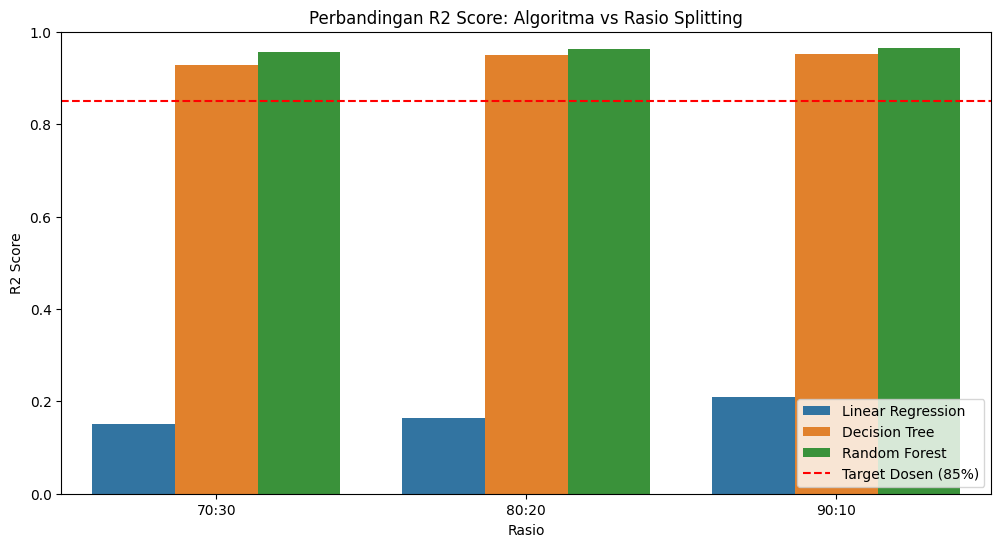


Kesimpulan: Model terbaik adalah Random Forest pada rasio 90:10 dengan akurasi (R2) sebesar 96.44%


In [10]:
print("7. MODEL EVALUATION & 8. MODEL COMPARISON")

df_results = pd.DataFrame(results)

# Tabel Perbandingan
print("\nTabel Hasil Evaluasi:")
display(df_results.sort_values(by="R2 Score", ascending=False))

# Visualisasi Grafik Perbandingan
plt.figure(figsize=(12, 6))
sns.barplot(x='Rasio', y='R2 Score', hue='Algoritma', data=df_results)
plt.axhline(0.85, color='red', linestyle='--', label='Target Dosen (85%)')
plt.title("Perbandingan R2 Score: Algoritma vs Rasio Splitting")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

print(f"\nKesimpulan: Model terbaik adalah {df_results.iloc[df_results['R2 Score'].idxmax()]['Algoritma']} "
      f"pada rasio {df_results.iloc[df_results['R2 Score'].idxmax()]['Rasio']} "
      f"dengan akurasi (R2) sebesar {best_r2:.2%}")

In [19]:
from IPython.display import clear_output
import numpy as np

# Inisialisasi riwayat agar tidak hilang saat sel dijalankan ulang
if 'riwayat_tes' not in globals():
    riwayat_tes = []

def input_angka(prompt, min_val, max_val):
    """Fungsi untuk validasi agar input hanya berupa angka dalam rentang tertentu"""
    while True:
        try:
            val = int(input(prompt))
            if min_val <= val <= max_val:
                return val
            print(f"⚠️ Masukkan angka antara {min_val} sampai {max_val}.")
        except ValueError:
            print("❌ Error: Harap masukkan angka bulat (bukan huruf).")

def jalankan_analisis():
    # Bersihkan layar sebelum memulai input baru
    clear_output(wait=True)
    print("\n" + "="*65)
    print("SISTEM ANALISIS DAMPAK TANGGAL MERAH")
    print("="*65)

    try:
        # 1. Pilih Tipe Toko dengan mapping size agar konsisten
        while True:
            tipe = input("Pilih Tipe Toko (A/B/C): ").upper()
            if tipe in ['A', 'B', 'C']:
                toko_ref = 4 if tipe == 'A' else (10 if tipe == 'B' else 33)
                size_ref = 202000 if tipe == 'A' else (126000 if tipe == 'B' else 39000)
                break
            print("⚠️ Pilih antara A, B, atau C.")

        # 2. Input Bulan
        bulan = input_angka("Masukkan Bulan (1-12): ", 1, 12)

        print(f"\n--- Simulasi 4 Minggu | Tipe {tipe} ---")

        hasil_mingguan = []
        total_omzet = 0

        # 3. Input 4 Minggu secara bertahap
        for mggu in range(1, 5):
            tgl_merah = input_angka(f"   Jumlah Tanggal Merah Minggu-{mggu} (0-7): ", 0, 7)

            is_holiday = 1 if tgl_merah > 0 else 0

            # Dinamisasi variabel 'Week' agar hasil tiap minggu tidak sama persis
            minggu_ke = (bulan * 4) - (4 - mggu)

            # Prediksi menggunakan model terbaik hasil tuning
            # Format: Store, Holiday, Size, Fuel, CPI, Unemp, Week, Month, Year
            input_raw = np.array([[toko_ref, is_holiday, size_ref, 3.5, 211.0, 6.0, minggu_ke, bulan, 2026]])
            input_scaled = final_scaler.transform(input_raw)
            pred_base = best_overall_model.predict(input_scaled)[0]

            # Kalkulasi omzet dengan penyesuaian dampak hari libur
            multiplier = 1 + (tgl_merah * 0.015)
            final_pred_idr = (pred_base * multiplier) * 17000 # Kurs Rupiah
            total_omzet += final_pred_idr

            emoji = "🎁" if tgl_merah > 0 else "🏠"
            status = f"{tgl_merah} Hari Libur" if tgl_merah > 0 else "Hari Biasa"
            hasil_mingguan.append(f"Minggu {mggu} ({emoji} {status}): Rp {final_pred_idr:,.0f}")

        # 4. Tampilkan Laporan Final dan Simpan Riwayat
        clear_output(wait=True)
        laporan = (f"📊 HASIL ANALISIS TIPE {tipe} (Bulan {bulan})\n" +
                   "\n".join([f" • {h}" for h in hasil_mingguan]) +
                   f"\n💰 TOTAL OMZET: Rp {total_omzet:,.0f}")

        riwayat_tes.append(laporan)

        print("\n" + "="*65)
        print("RIWAYAT PENGUJIAN")
        print("="*65)
        for r in riwayat_tes:
            print(r)
            print("-" * 30)

    except Exception as e:
        print(f"❌ Terjadi kesalahan teknis: {e}")

# Menu Utama Program
while True:
    print("\nSISTEM PREDIKSI PENJUALAN WALMART")
    print("1. Jalankan Analisis")
    print("2. Hapus Riwayat (Bersihkan Layar)")
    print("3. Keluar")
    p = input("Pilih Menu: ")

    if p == '1':
        jalankan_analisis()
    elif p == '2':
        riwayat_tes = []
        clear_output()
        print("✅ Riwayat dan tampilan telah dibersihkan total.")
    elif p == '3':
        print("Sesi berakhir.")
        break
    else:
        print("⚠️ Pilih menu 1, 2, atau 3.")


SISTEM PREDIKSI PENJUALAN WALMART
1. Jalankan Analisis
2. Hapus Riwayat (Bersihkan Layar)
3. Keluar
Pilih Menu: 3
Sesi berakhir.
